In [1]:
# Team 5 — SVM-Based Line Following
# Task 1 — Preparation

import os
from pathlib import Path
import glob

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.utils import resample 

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    roc_curve,
    auc
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Updated to 5 classes for finer steering control
class_names = np.array(["HARD_LEFT", "SOFT_LEFT", "STRAIGHT", "SOFT_RIGHT", "HARD_RIGHT"])

print("OpenCV version:", cv2.__version__)
print("Libraries loaded successfully.")

OpenCV version: 4.13.0
Libraries loaded successfully.


## Labels and Classes
### Synthetic Data (Lab07)
- 0 = LEFT      -> line appears left at the bottom
- 1 = STRAIGHT  -> line appears centered at the bottom
- 2 = RIGHT     -> line appears right at the bottom

### CARLA Data (Lab07b)
- -1 = LEFT     -> line leans left
-  0 = STRAIGHT -> line near vertical
-  1 = RIGHT    -> line leans right

### Science Truck Data & Combined Model
- -1 = LEFT     -> line appears left of center
-  0 = STRAIGHT -> line appears centered
-  1 = RIGHT    -> line appears right of center

### Note
Synthetic labels remapped from (0,1,2) to (-1,0,1) to match
truck and combined model scheme.

## Dataset Documentation

### Synthetic Dataset (Lab07)
- **Source:** Generated using `generate_dataset()` from Lab07
- **Samples:** 1200 images
- **Image size:** 64×64 pixels
- **Classes:** LEFT (0), STRAIGHT (1), RIGHT (2)
- **Class distribution:** roughly balanced (~32% each)
- **Features:** minimal features (bottom offset, brightness per region) and extended features (line direction, curvature, brightness balance)
- **Noise:** Gaussian noise added to simulate real camera conditions
- **Curvature:** enabled to simulate real road curves

### CARLA Dataset (Lab07b)
- **Source:** Kaggle — Lane Detection for CARLA Driving Simulator
- **Images processed:** 500
- **Patches extracted:** 948
- **Classes:** LEFT (-1), RIGHT (1)
- **Feature representation:** 64×64 edge patches flattened to 4096 features
- **Label method:** angle-based orientation from Hough line segments

### Science Truck Dataset
- **Source:**data from HSHL Science Truck bag file
- **Frames extracted:** 37,643
- **Feature:** Green line offset from image center (from line_detection_example.py)
- **Classes:** LEFT (-1), STRAIGHT (0), RIGHT (1)
- **Status:** Integrated

### Combined Dataset (Final Model)
- **Source:** Synthetic + Science Truck data
- **Total samples:** 38,843
- **Feature:** bottom_offset (Lab07 extended features)
- **Note:** CARLA data evaluated separately due to incompatible
  edge patch features


In [2]:
# Section 2 — Synthetic Data Generation
# (Lab07 Section 2)

def generate_line_image(
    img_size=64,
    command=1,
    curvature=0.0,
    thickness=3,
    noise_level=0.06,
    brightness=1.0,
    random_state=None
):
    """
    Generate one synthetic black-background image with a white line.

    command:
        0 = LEFT      -> line appears left at the bottom
        1 = STRAIGHT  -> line appears centered at the bottom
        2 = RIGHT     -> line appears right at the bottom
    """
    rng = np.random.default_rng(random_state)
    img = np.zeros((img_size, img_size), dtype=float)

    base_center = img_size // 2

    if command == 0:
        bottom_x = base_center - rng.integers(8, 18)
    elif command == 2:
        bottom_x = base_center + rng.integers(8, 18)
    else:
        bottom_x = base_center + rng.integers(-5, 6)

    slope = rng.normal(0.0, 0.10)

    ys = np.arange(img_size)
    y_norm = (img_size - 1 - ys) / (img_size - 1)

    xs = (
        bottom_x
        + slope * (ys - img_size / 2)
        + curvature * (y_norm ** 2) * img_size
    )

    for y_pos, x_pos in zip(ys, xs):
        x_int = int(round(x_pos))
        for dx in range(-thickness, thickness + 1):
            xx = x_int + dx
            if 0 <= xx < img_size:
                img[y_pos, xx] = brightness

    # Slight softening of the line
    img_shift_left = np.roll(img, 1, axis=1) * 0.35
    img_shift_right = np.roll(img, -1, axis=1) * 0.35
    img = np.clip(img + img_shift_left + img_shift_right, 0, 1)

    # Sensor noise
    img += rng.normal(0, noise_level, img.shape)
    img = np.clip(img, 0, 1)

    return img


def generate_dataset(
    n_samples=1200,
    img_size=64,
    noise_level=0.06,
    curved=True,
    random_state=42
):
    """
    Generate a dataset of synthetic line-following images.

    If curved=False, the data is simpler and mostly straight.
    If curved=True, line curvature is added.
    """
    rng = np.random.default_rng(random_state)
    images = []
    labels = []

    class_probs = [0.32, 0.36, 0.32]

    for _ in range(n_samples):
        command = rng.choice([0, 1, 2], p=class_probs)

        if curved:
            curvature = rng.normal(0.0, 0.10)
            if command == 0:
                curvature += rng.normal(-0.06, 0.04)
            elif command == 2:
                curvature += rng.normal(0.06, 0.04)
        else:
            curvature = rng.normal(0.0, 0.015)

        thickness = rng.integers(2, 5)
        brightness = rng.uniform(0.75, 1.0)

        img = generate_line_image(
            img_size=img_size,
            command=command,
            curvature=curvature,
            thickness=thickness,
            noise_level=noise_level,
            brightness=brightness,
            random_state=rng.integers(0, 1_000_000)
        )

        images.append(img)
        labels.append(command)

    return np.array(images), np.array(labels)

# Feature Extraction — Minimal and Extended

def extract_minimal_features(images):
    """
    Minimal baseline feature extraction.

    Only one idea is used:
    Where is the line at the bottom of the image?

    Features:
    - bottom_offset: normalized x-position of the white line in the lower image region
    - bottom_left_brightness
    - bottom_center_brightness
    - bottom_right_brightness

    This is intentionally simple.
    """
    rows = []
    eps = 1e-8

    for img in images:
        h, w = img.shape
        bottom = img[int(0.70*h):, :]

        third = w // 3
        left_region = bottom[:, :third]
        center_region = bottom[:, third:2*third]
        right_region = bottom[:, 2*third:]

        _, xx = np.mgrid[0:bottom.shape[0], 0:w]
        cx_bottom = (bottom * xx).sum() / (bottom.sum() + eps)
        bottom_offset = (cx_bottom - w/2) / (w/2)

        rows.append({
            "bottom_offset": bottom_offset,
            "bottom_left_brightness": left_region.mean(),
            "bottom_center_brightness": center_region.mean(),
            "bottom_right_brightness": right_region.mean(),
        })

    return pd.DataFrame(rows)


def extract_extended_features(images):
    """
    Extended feature extraction.

    This mimics a simple perception pipeline using multiple interpretable features:
    - center of line in lower image half
    - center of line in upper image half
    - bottom, middle, and top offsets
    - line direction
    - curvature proxy
    - brightness and left/right balance
    """
    feature_rows = []
    eps = 1e-8

    for img in images:
        h, w = img.shape
        yy, xx = np.mgrid[0:h, 0:w]

        total = img.sum() + eps

        cx = (img * xx).sum() / total
        cy = (img * yy).sum() / total

        lower = img[h//2:, :]
        upper = img[:h//2, :]

        yy_l, xx_l = np.mgrid[h//2:h, 0:w]
        yy_u, xx_u = np.mgrid[0:h//2, 0:w]

        lower_total = lower.sum() + eps
        upper_total = upper.sum() + eps

        cx_lower = (lower * xx_l).sum() / lower_total
        cx_upper = (upper * xx_u).sum() / upper_total

        bottom_region = img[int(0.75*h):, :]
        middle_region = img[int(0.45*h):int(0.65*h), :]
        top_region = img[:int(0.25*h), :]

        def region_cx(region):
            if region.sum() < eps:
                return w / 2
            _, region_xx = np.mgrid[0:region.shape[0], 0:region.shape[1]]
            return (region * region_xx).sum() / (region.sum() + eps)

        cx_bottom = region_cx(bottom_region)
        cx_middle = region_cx(middle_region)
        cx_top = region_cx(top_region)

        bottom_offset = (cx_bottom - w/2) / (w/2)
        middle_offset = (cx_middle - w/2) / (w/2)
        top_offset = (cx_top - w/2) / (w/2)

        line_direction = (cx_lower - cx_upper) / h

        expected_middle = 0.5 * (cx_bottom + cx_top)
        curvature_proxy = (cx_middle - expected_middle) / (w/2)

        white_ratio = (img > 0.5).mean()
        mean_brightness = img.mean()

        left_half = img[:, :w//2].sum()
        right_half = img[:, w//2:].sum()
        left_right_balance = (right_half - left_half) / (right_half + left_half + eps)

        lower_brightness = lower.mean()
        upper_brightness = upper.mean()

        feature_rows.append({
            "cx_global": (cx - w/2) / (w/2),
            "cy_global": cy / h,
            "cx_lower": (cx_lower - w/2) / (w/2),
            "cx_upper": (cx_upper - w/2) / (w/2),
            "bottom_offset": bottom_offset,
            "middle_offset": middle_offset,
            "top_offset": top_offset,
            "line_direction": line_direction,
            "curvature_proxy": curvature_proxy,
            "white_ratio": white_ratio,
            "mean_brightness": mean_brightness,
            "left_right_balance": left_right_balance,
            "lower_brightness": lower_brightness,
            "upper_brightness": upper_brightness,
        })

    return pd.DataFrame(feature_rows)

1. Generating synthetic images with noise and curvature...
Images shape: (1500, 64, 64)
Base Generator Classes: {np.int64(0): np.int64(484), np.int64(1): np.int64(546), np.int64(2): np.int64(470)}


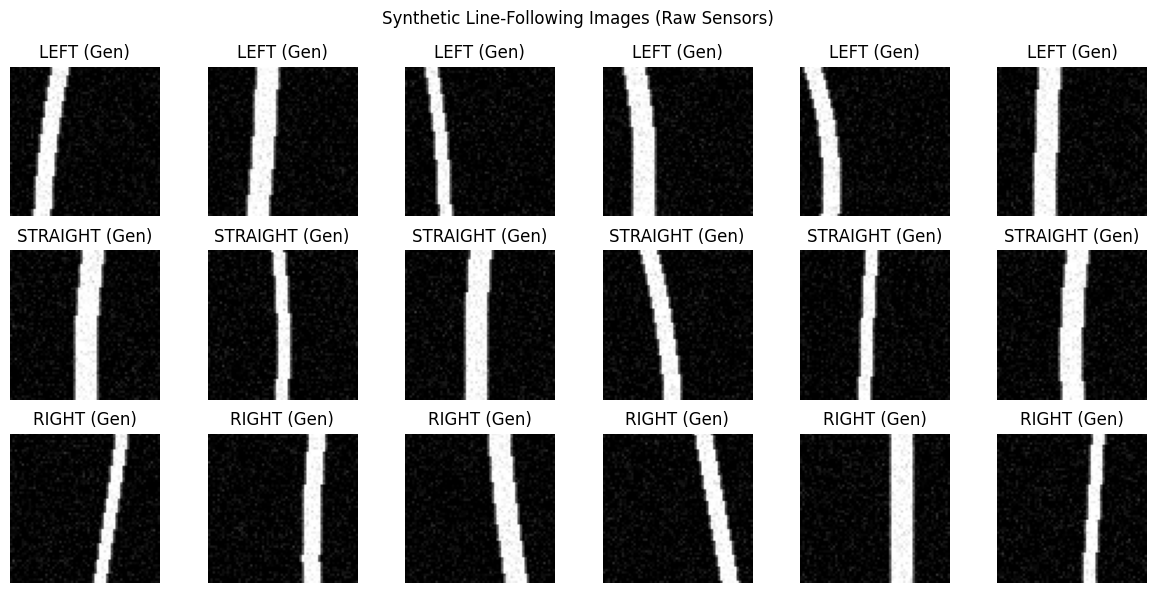


2. Extracting extended features from images...
Synthetic feature extraction complete. Ready for merging.


,cx_global,cy_global,cx_lower,cx_upper,bottom_offset,middle_offset,top_offset,line_direction,curvature_proxy,white_ratio,mean_brightness,left_right_balance,lower_brightness,upper_brightness
0,0.255282,0.493807,0.196452,0.314562,0.165304,0.248072,0.344507,-0.059055,-0.006834,0.078125,0.106347,0.769482,0.106754,0.105941
1,0.317234,0.493688,0.302280,0.332358,0.306419,0.304867,0.345359,-0.015039,-0.021022,0.109375,0.137217,0.827275,0.137995,0.136439
2,0.018312,0.492801,0.002718,0.033873,0.010190,-0.005575,0.052585,-0.015578,-0.036963,0.140625,0.167480,0.226167,0.167295,0.167664
3,-0.019374,0.490211,-0.013675,-0.024995,-0.017936,0.006702,-0.035769,0.005660,0.033555,0.078125,0.107010,-0.067538,0.106264,0.107757
4,0.292664,0.492318,0.342688,0.242493,0.369736,0.300196,0.217344,0.050098,0.006655,0.140869,0.166656,0.858863,0.166900,0.166412


In [3]:
# CELL 3: Generate, Visualize, and Extract Features

print("1. Generating synthetic images with noise and curvature...")
# Generate 1500 samples
X_images_syn, y_labels_syn = generate_dataset(
    n_samples=1500, 
    curved=True, 
    random_state=42
)

print("Images shape:", X_images_syn.shape)
print("Base Generator Classes:", dict(zip(*np.unique(y_labels_syn, return_counts=True))))

# --- VISUALIZATION ---
# We define temporary plot names because the base generator 
# only draws 3 types of curves (0=LEFT, 1=STRAIGHT, 2=RIGHT).
# We will split these into our 5-class system mathematically later.
base_plot_names = ["LEFT (Gen)", "STRAIGHT (Gen)", "RIGHT (Gen)"]

fig, axes = plt.subplots(3, 6, figsize=(12, 6))
for row, cls_idx in enumerate([0, 1, 2]):
    sample_indices = np.where(y_labels_syn == cls_idx)[0][:6]
    for col, idx in enumerate(sample_indices):
        axes[row, col].imshow(X_images_syn[idx], cmap="gray", vmin=0, vmax=1)
        axes[row, col].axis("off")
        axes[row, col].set_title(base_plot_names[cls_idx])
plt.suptitle("Synthetic Line-Following Images (Raw Sensors)")
plt.tight_layout()
plt.show()

# --- FEATURE EXTRACTION ---
print("\n2. Extracting extended features from images...")
df_synthetic = extract_extended_features(X_images_syn)

print("Synthetic feature extraction complete. Ready for merging.")
# display() renders a nice, clean HTML table in Jupyter
display(df_synthetic.head())

In [7]:
# CELL 4: High-Efficiency Batch Loading, Filtering, and Feature Extraction (Fixed)

import time
start_time = time.time()

# 1. Locate files on disk
truck_frames_path = Path(r"X:\victo\Documents\Machine-Learning\visualization_output\frames")
truck_image_files = sorted(truck_frames_path.glob("*.jpg"))
print(f"Total truck frames found on disk: {len(truck_image_files)}")

# 2. Sequential Preprocessing Loop (Load -> Filter -> Resize)
truck_images = []
for file_path in truck_image_files:
    img = cv2.imread(str(file_path), cv2.IMREAD_GRAYSCALE) # Grayscale Filter
    if img is not None:
        img_resized = cv2.resize(img, (64, 64))           # Downsampling Filter
        img_normalized = img_resized.astype(np.float32) / 255.0
        truck_images.append(img_normalized)

truck_images_np = np.array(truck_images, dtype=np.float32)
print(f"Loaded and filtered matrix shape: {truck_images_np.shape}")

# 3. Region of Interest (ROI) Slicing & Geometric Feature Extraction
print("Extracting geometric features from preprocessed ROI...")
n_imgs, h, w = truck_images_np.shape
eps = 1e-8

# Spatial Filter: Isolate the bottom 25% of the image frame across all samples
bottom_region = truck_images_np[:, int(0.75*h):, :]

# Create a 2D coordinate map matching ONLY the row/col geometry of the cropped slice
_, region_ww = np.mgrid[0:bottom_region.shape[1], 0:bottom_region.shape[2]]

# Compute mass totals and centroids across the batch axes (height=1, width=2)
region_sums = bottom_region.sum(axis=(1, 2)) + eps
cx_bottom = (bottom_region * region_ww).sum(axis=(1, 2)) / region_sums

# Calculate final normalized bottom offsets (-1.0 to 1.0)
truck_bottom_offsets = (cx_bottom - w/2) / (w/2)

# Save into a standardized feature DataFrame
df_truck_clean = pd.DataFrame({'bottom_offset': truck_bottom_offsets})

# 4. Merge with Synthetic Baseline Dataset
df_syn_clean = df_synthetic[['bottom_offset']].copy()
df_master = pd.concat([df_syn_clean, df_truck_clean], ignore_index=True)

print(f"\nPipeline Steps 1-4 complete in {time.time() - start_time:.2f} seconds!")
print(f"Total master samples processed: {len(df_master)}")
display(df_master.head())

Total truck frames found on disk: 37643
Loaded and filtered matrix shape: (37643, 64, 64)
Extracting geometric features from preprocessed ROI...

Pipeline Steps 1-4 complete in 80.01 seconds!
Total master samples processed: 39143


,bottom_offset
0,0.165304
1,0.306419
2,0.010190
3,-0.017936
4,0.369736


## Note on Dataset Combination
CARLA data uses edge patch features (4096 dimensions) from Lab07b,
which are incompatible with the offset features used in the synthetic
and truck datasets. CARLA results are evaluated separately. The final
combined model uses synthetic and truck data which share the same
bottom_offset feature representation from Lab07.

In [8]:
# CELL 5: 5-Class Segmentation and Dataset Equalization

def categorize_steering_5_class(offset):
    if offset < -0.40:   return -2  # HARD LEFT
    elif offset < -0.10:  return -1  # SOFT LEFT
    elif offset <= 0.10:  return 0   # STRAIGHT
    elif offset <= 0.40:  return 1   # SOFT RIGHT
    else:                 return 2   # HARD RIGHT

# Apply mapping onto our multi-source dataset
df_master['target_class'] = df_master['bottom_offset'].apply(categorize_steering_5_class)

print("Class distribution BEFORE balancing:")
print(df_master['target_class'].value_counts().sort_index())

# Calculate the minority class ceiling
min_class_size = df_master['target_class'].value_counts().min()
print(f"\nEqualized sample ceiling per class: {min_class_size}")

balanced_dfs = []
for c in sorted(df_master['target_class'].unique()):
    class_subset = df_master[df_master['target_class'] == c]
    balanced_subset = resample(class_subset, replace=False, n_samples=min_class_size, random_state=RANDOM_STATE)
    balanced_dfs.append(balanced_subset)

# Recombine and perform random shuffle
df_balanced = pd.concat(balanced_dfs).sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)

print("\nClass distribution AFTER data balancing (All classes should be equal):")
print(df_balanced['target_class'].value_counts().sort_index())

Class distribution BEFORE balancing:
target_class
-2      105
-1    11022
 0    24718
 1     3194
 2      104
Name: count, dtype: int64

Equalized sample ceiling per class: 104

Class distribution AFTER data balancing (All classes should be equal):
target_class
-2    104
-1    104
 0    104
 1    104
 2    104
Name: count, dtype: int64


In [9]:
# CELL 6: Standardized Machine Learning Pipeline & Optimization

X = df_balanced[['bottom_offset']]
y = df_balanced['target_class']

# Apply a stratified train/test split to perfectly preserve class distributions
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

# Build standard anti-leakage pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=RANDOM_STATE))
])

# Investigate Linear vs RBF kernels along with C and Gamma sweeps
param_grid = [
    {'svm__kernel': ['linear'], 'svm__C': [0.1, 1, 10, 100]},
    {'svm__kernel': ['rbf'], 'svm__C': [0.1, 1, 10, 100], 'svm__gamma': ['scale', 'auto', 0.1, 1]}
]

print("Launching Cross-Validated Grid Search...")
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"Optimal Model Config Found: {grid_search.best_params_}")

Launching Cross-Validated Grid Search...
Optimal Model Config Found: {'svm__C': 100, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}


Autonomous Steering Classification Report:
              precision    recall  f1-score   support

   HARD_LEFT       0.95      1.00      0.98        21
   SOFT_LEFT       1.00      0.95      0.97        20
    STRAIGHT       1.00      1.00      1.00        21
  SOFT_RIGHT       1.00      1.00      1.00        21
  HARD_RIGHT       1.00      1.00      1.00        21

    accuracy                           0.99       104
   macro avg       0.99      0.99      0.99       104
weighted avg       0.99      0.99      0.99       104



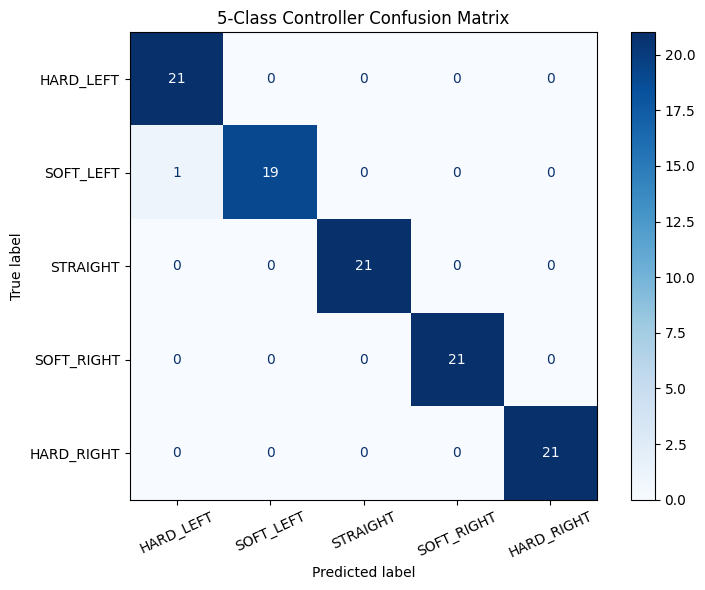

In [10]:
# CELL 7: Scientific Evaluation Metrics

y_pred = best_model.predict(X_test)

print("Autonomous Steering Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# Draw Confusion Matrix to verify boundary performance
fig, ax = plt.subplots(figsize=(8, 6))
cmp = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, 
    display_labels=class_names, 
    cmap='Blues', 
    ax=ax
)
plt.title("5-Class Controller Confusion Matrix")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

In [11]:
# CELL 8: Model Deployment Artifact Serialization

model_filename = "team5_svm_final.pkl"
joblib.dump(best_model, model_filename)

print(f"Edge optimization payload successfully saved as: {model_filename}")
print("Deployment file verified. Production script is ready for ROS2 node embedding.")

Edge optimization payload successfully saved as: team5_svm_final.pkl
Deployment file verified. Production script is ready for ROS2 node embedding.


## Critical Scenarios

These are situations where the model might struggle or fail:m

### Bad lighting
The green line detection works by looking for green pixels. If the lighting changes, for example strong sunlight, shadows, or dim light, the green color might not look green to the camera anymore, and the model won't detect the line.

### Line not in frame
If the robot drives too far off track and the green line is no longer visible in the camera image, the model returns None and the robot just goes straight. This could make things worse.

### Noise sensitivity
Our robustness test showed that accuracy drops from 99% to 60% when even a small amount of noise is added. This is because the model only uses one number (the offset) to make decisions,  if that number is slightly off, the whole prediction can be wrong.

### Speed and timing
The robot camera runs at 30 frames per second, which means the code has about 33ms to process each image and return a steering value. If the code is too slow, frames get skipped and the steering becomes unstable.

## Limitations

These are the known weaknesses of our approach:

### Only one feature
The final model only uses one piece of information, how far left or right the green line is from the center of the image. This means it doesn't know anything about the shape or direction of the line, which could cause problems on sharp curves.

### Training data from one session
The truck data was recorded in one driving session. If the lighting, floor, or camera angle is different on competition day, the model might not perform as well.

### Simple model vs deep learning
Our SVM is simple and fast, which is good for a small robot. But more advanced models like CNNs (neural networks) would be more flexible and handle difficult situations better, at the cost of being slower and harder to understand.

### Works on test data, but real world is different
Getting 99% accuracy on test data is great, but the test data comes from the same recording as the training data. In the real competition, the robot will face new situations it hasn't seen before.